**Import Libraries**

In [11]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import resample

**Load Dataset**

In [12]:
df1 = pd.read_csv("Truth_Seeker_Model_Dataset.csv")
df2 = pd.read_csv("Twitter Analysis.csv")

print("DF1 Shape:", df1.shape)
print("DF2 Shape:", df2.shape)

DF1 Shape: (134198, 9)
DF2 Shape: (134198, 64)


In [13]:
print(df1.columns)
print(df2.columns)

Index(['Unnamed: 0', 'author', 'statement', 'target', 'BinaryNumTarget',
       'manual_keywords', 'tweet', '5_label_majority_answer',
       '3_label_majority_answer'],
      dtype='object')
Index(['Unnamed: 0', 'majority_target', 'statement', 'BinaryNumTarget',
       'tweet', 'followers_count', 'friends_count', 'favourites_count',
       'statuses_count', 'listed_count', 'following', 'embeddings', 'BotScore',
       'BotScoreBinary', 'cred', 'normalize_influence', 'mentions', 'quotes',
       'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count',
       'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',


In [14]:
print(df2['BinaryNumTarget'].value_counts())

BinaryNumTarget
1.0    68930
0.0    65268
Name: count, dtype: int64


**Combine Datasets**

In [15]:
df = pd.concat([df1, df2], ignore_index=True)

print("Combined Distribution:")
print(df['BinaryNumTarget'].value_counts())

Combined Distribution:
BinaryNumTarget
1.0    137860
0.0    130536
Name: count, dtype: int64


**Balance Dataset**

In [16]:
from sklearn.utils import resample

fake = df[df.BinaryNumTarget == 0]
real = df[df.BinaryNumTarget == 1]

print("Before Balancing:", len(fake), len(real))

min_samples = min(len(fake), len(real))

fake = resample(fake, replace=False, n_samples=min_samples, random_state=42)
real = resample(real, replace=False, n_samples=min_samples, random_state=42)

df = pd.concat([fake, real])

print("After Balancing:")
print(df['BinaryNumTarget'].value_counts())

Before Balancing: 130536 137860
After Balancing:
BinaryNumTarget
0.0    130536
1.0    130536
Name: count, dtype: int64


In [28]:
print(df.columns)

Index(['Unnamed: 0', 'author', 'statement', 'target', 'BinaryNumTarget',
       'manual_keywords', 'tweet', '5_label_majority_answer',
       '3_label_majority_answer', 'majority_target', 'followers_count',
       'friends_count', 'favourites_count', 'statuses_count', 'listed_count',
       'following', 'embeddings', 'BotScore', 'BotScoreBinary', 'cred',
       'normalize_influence', 'mentions', 'quotes', 'replies', 'retweets',
       'favourites', 'hashtags', 'URLs', 'unique_count', 'total_count',
       'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
       'Word count', 'Max word length', 'Min word length',
       'Average word lengt

In [29]:
df['text'] = df['tweet']

**Text Cleaning**

In [30]:
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    return text.lower()

df['clean_text'] = df['text'].apply(clean_text)

print("\nSample Cleaned Text:")
print(df['clean_text'].iloc[0])


Sample Cleaned Text:
   only the southern border is open  u s  taxpayers must now redistribute their wealth to those from supposed poorer nations who are dark skinned  


**Feature Extraction**

In [31]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['BinaryNumTarget']

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (261072, 5000)


**Train-Test Split**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Training**

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Evaluating Model**

Accuracy: 0.9837403045101982

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     25963
         1.0       0.98      0.98      0.98     26252

    accuracy                           0.98     52215
   macro avg       0.98      0.98      0.98     52215
weighted avg       0.98      0.98      0.98     52215



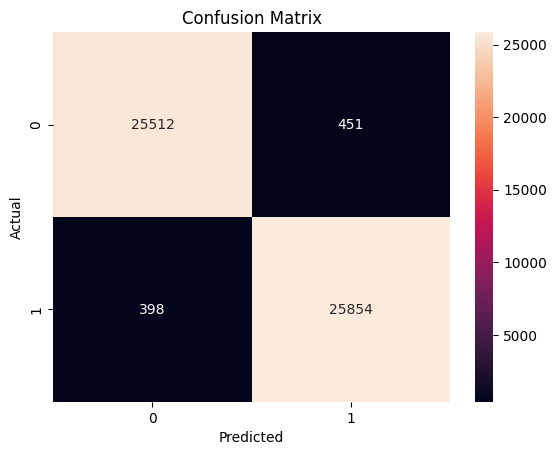

In [34]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Manual vs AI comparison**

In [52]:
sample_tweets = [
    "Pfizer vaccine contains graphene",
    "Government announces new policy",
    "Aliens landed in Mumbai",
    "New AI model improves healthcare",
    "Hydroxychloroquine cures covid instantly",
    "Scientists confirm that humans can breathe underwater without equipments",
    "Government announces new tax reforms to support small businesses",
    "Eating garlic daily guarantees complete immunity from all diseases",
    "Researchers are studying the effects of screen time on sleep quality",
    "Some experts claim certain foods may help improve immunity"
]

manual_labels = [0, 1, 0, 1, 0, 0, 1, 0, 1, 1]

for i, tweet in enumerate(sample_tweets):
    cleaned = clean_text(tweet)
    vector = vectorizer.transform([cleaned])
    pred = model.predict(vector)[0]

    print("\nTweet:", tweet)
    print("Manual:", "REAL" if manual_labels[i]==1 else "FAKE")
    print("Model:", "REAL" if pred==1 else "FAKE")


Tweet: Pfizer vaccine contains graphene
Manual: FAKE
Model: FAKE

Tweet: Government announces new policy
Manual: REAL
Model: REAL

Tweet: Aliens landed in Mumbai
Manual: FAKE
Model: REAL

Tweet: New AI model improves healthcare
Manual: REAL
Model: REAL

Tweet: Hydroxychloroquine cures covid instantly
Manual: FAKE
Model: FAKE

Tweet: Scientists confirm that humans can breathe underwater without equipments
Manual: FAKE
Model: FAKE

Tweet: Government announces new tax reforms to support small businesses
Manual: REAL
Model: REAL

Tweet: Eating garlic daily guarantees complete immunity from all diseases
Manual: FAKE
Model: FAKE

Tweet: Researchers are studying the effects of screen time on sleep quality
Manual: REAL
Model: REAL

Tweet: Some experts claim certain foods may help improve immunity
Manual: REAL
Model: FAKE


In [36]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake = np.argsort(coefficients)[:20]
top_real = np.argsort(coefficients)[-20:]

print("\nTop Fake Words:")
print([feature_names[i] for i in top_fake])

print("\nTop Real Words:")
print([feature_names[i] for i in top_real])


Top Fake Words:
['biden', 'vaccine', 'pelosi', 'hydroxychloroquine', 'cage', 'refusing', 'mothers', 'fauci', 'added', 'arizona', 'vaccination', 'vaccinated', 'ballots', 'preexisting', 'mayhem', 'floyd', 'pardoned', 'bidens', 'signature', 'preexisting condition']

Top Real Words:
['background', 'precinct', 'lobbyists', 'highest', 'blindness', 'gloves', 'millionaires', 'veterans', 'unpopular', 'flu shot', 'capita', 'graduating', 'look bad', 'recruiting', 'marriage', 'overdose', 'apprehended', 'eisenhower', 'heroin', 'marijuana']


In [37]:
fake_keywords = ['graphene','hydroxychloroquine','mrna','pfizer','nuremberg']

for word in fake_keywords:
    if word in feature_names:
        idx = list(feature_names).index(word)
        print(word, "-> weight:", coefficients[idx])
    else:
        print(word, "-> NOT found")

graphene -> weight: -1.6651345573321126
hydroxychloroquine -> weight: -9.84094533377503
mrna -> weight: -3.541621637836665
pfizer -> weight: -5.637973622609325
nuremberg -> weight: -2.58958445762142


In [38]:
tests = [
    "Pfizer vaccine contains graphene",
    "Pfizer vaccine tested in lab",
    "Pfizer vaccine may contain unknown substances"
]

for t in tests:
    cleaned = clean_text(t)
    vector = vectorizer.transform([cleaned])
    pred = model.predict(vector)[0]
    print(t, "->", "REAL" if pred==1 else "FAKE")

Pfizer vaccine contains graphene -> FAKE
Pfizer vaccine tested in lab -> FAKE
Pfizer vaccine may contain unknown substances -> FAKE


In [39]:
bias_test = [
    "Pfizer releases vaccine data",
    "Pfizer vaccine contains graphene"
]

for t in bias_test:
    cleaned = clean_text(t)
    vector = vectorizer.transform([cleaned])
    pred = model.predict(vector)[0]
    print(t, "->", "REAL" if pred==1 else "FAKE")

Pfizer releases vaccine data -> FAKE
Pfizer vaccine contains graphene -> FAKE


In [42]:
def predict_tweet(tweet):
    cleaned = clean_text(tweet)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0]

    label = "REAL" if prediction == 1 else "FAKE"

    print("\nTweet:", tweet)
    print("Prediction:", label)
    print("Confidence:", max(probability))

**Testing**

In [41]:
while True:
    user_input = input("\nEnter a tweet (or type 'exit' to stop): ")

    if user_input.lower() == 'exit':
        print("Exiting...")
        break

    predict_tweet(user_input)


Enter a tweet (or type 'exit' to stop): The thing I find most surprising is how few people try to improve the default settings of their life.

Tweet: The thing I find most surprising is how few people try to improve the default settings of their life.
Prediction: REAL
Confidence: 0.5232202449476632

Enter a tweet (or type 'exit' to stop): ust bought the moon. Will allow free speech on all lunar surfaces

Tweet: ust bought the moon. Will allow free speech on all lunar surfaces
Prediction: FAKE
Confidence: 0.8293264832096604

Enter a tweet (or type 'exit' to stop): Nobody likes me and I've made peace with that. 

Tweet: Nobody likes me and I've made peace with that. 
Prediction: REAL
Confidence: 0.8066529306786548

Enter a tweet (or type 'exit' to stop): Heard the word 'walk' from 3 rooms away. Already at the door. Already crying. 

Tweet: Heard the word 'walk' from 3 rooms away. Already at the door. Already crying. 
Prediction: FAKE
Confidence: 0.6255235038070815

Enter a tweet (or typ

In [43]:
y_pred = model.predict(X_test)

print("Prediction Distribution:")
print(pd.Series(y_pred).value_counts())

Prediction Distribution:
1.0    26305
0.0    25910
Name: count, dtype: int64
